In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import boxcox

In [2]:
df = pd.read_csv("D:/M.Tech/Semester 1/Foundations of Data Engineering/water_potability.csv")

In [3]:
skew_values = df.skew()
print("Skewness:\n", skew_values)

Skewness:
 ph                 0.027796
Hardness          -0.039342
Solids             0.621634
Chloramines       -0.012098
Sulfate           -0.041184
Conductivity       0.264490
Organic_carbon     0.025533
Trihalomethanes   -0.085161
Turbidity         -0.007817
Potability         0.450784
dtype: float64


In [4]:
kurt_values = df.kurt()
print("Kurtosis:\n", kurt_values)

Kurtosis:
 ph                 1.376090
Hardness           0.615772
Solids             0.442826
Chloramines        0.589901
Sulfate            1.789965
Conductivity      -0.277093
Organic_carbon     0.044409
Trihalomethanes    0.407102
Turbidity         -0.062801
Potability        -1.797892
dtype: float64


In [5]:
mean_values = df.mean()
median_values = df.median()
std_values = df.std()
pearson_skewness = 3 * (mean_values - median_values) / std_values
print("Pearson's Skewness:\n", pearson_skewness)

Pearson's Skewness:
 ph                 1.812663e-15
Hardness          -5.457438e-02
Solids             3.716429e-01
Chloramines       -1.520231e-02
Sulfate           -9.436521e-15
Conductivity       1.603536e-01
Organic_carbon     6.042538e-02
Trihalomethanes    0.000000e+00
Turbidity          4.520325e-02
Potability         2.398958e+00
dtype: float64


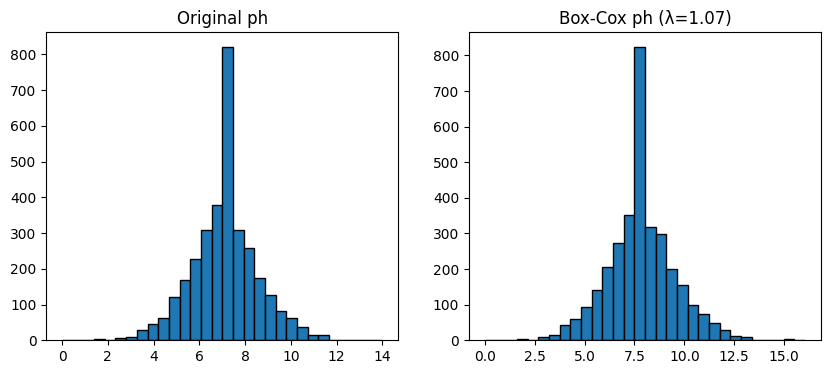

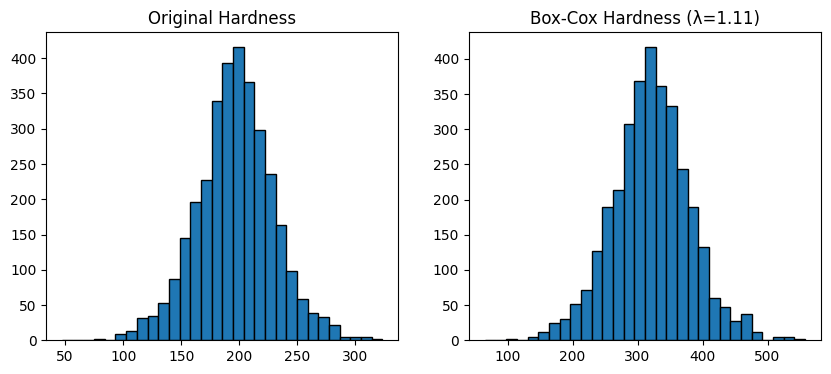

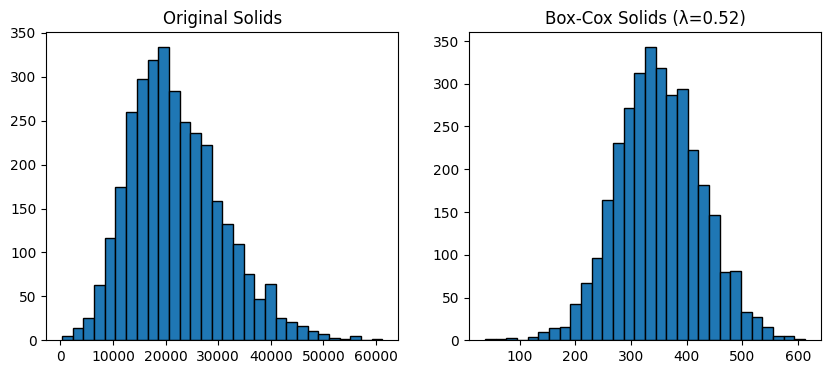

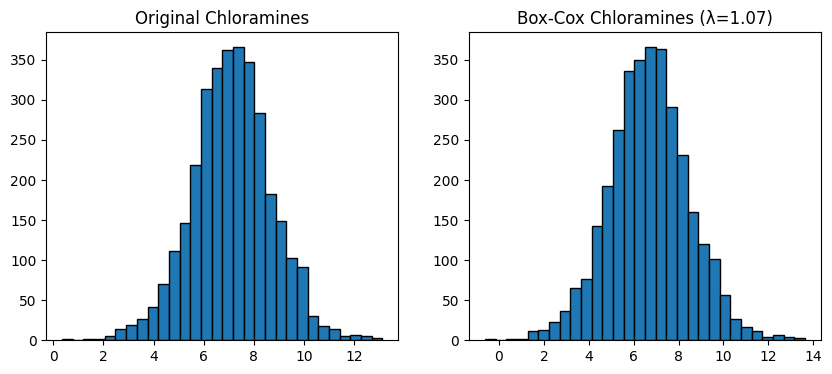

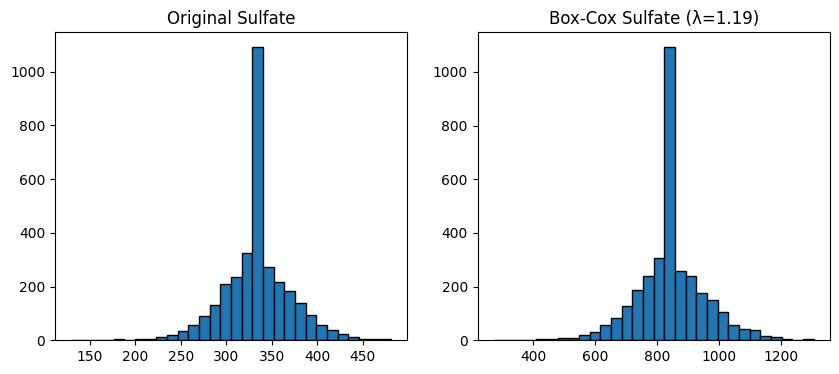

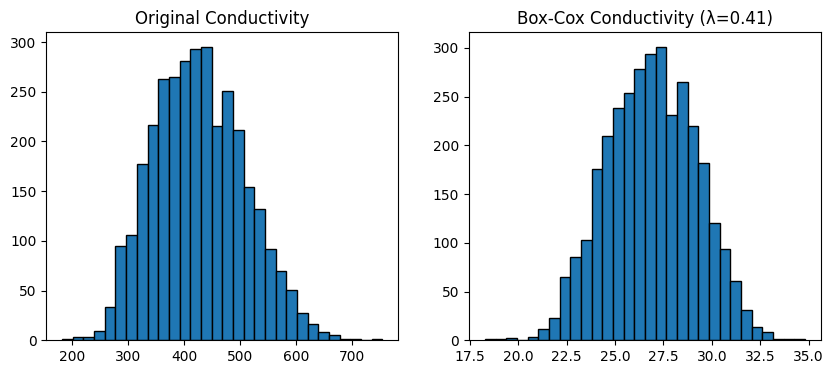

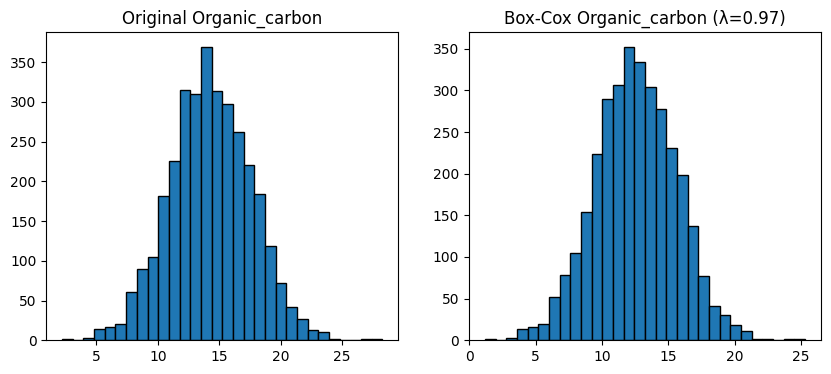

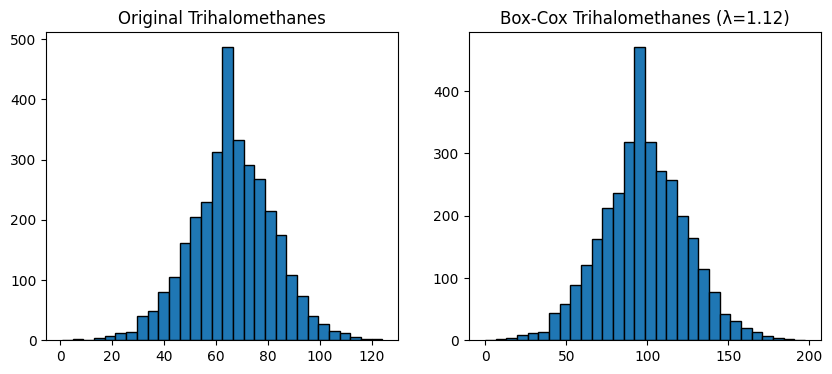

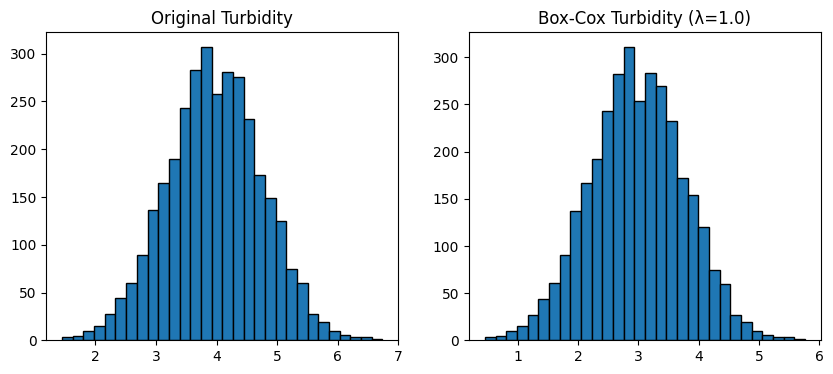

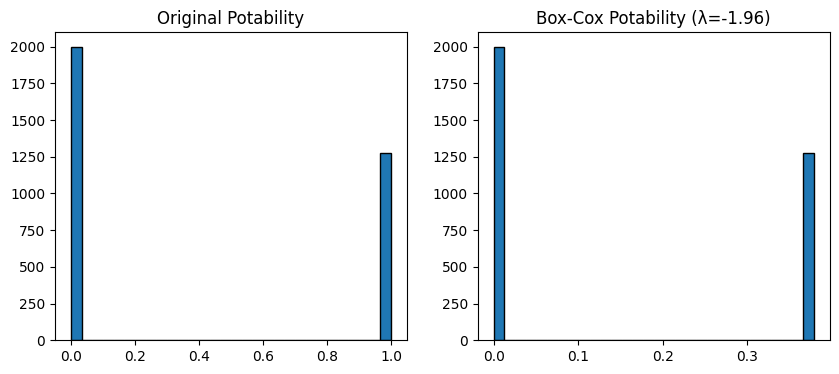

ph -> Optimal λ = 1.071
Hardness -> Optimal λ = 1.113
Solids -> Optimal λ = 0.524
Chloramines -> Optimal λ = 1.065
Sulfate -> Optimal λ = 1.190
Conductivity -> Optimal λ = 0.412
Organic_carbon -> Optimal λ = 0.969
Trihalomethanes -> Optimal λ = 1.121
Turbidity -> Optimal λ = 1.004
Potability -> Optimal λ = -1.960


In [6]:
boxcox_results = {}

for col in df.columns:
    data = df[col].values
    
    # Box-Cox requires strictly positive values
    if (data <= 0).any():
        # Shift data by +1 (or a small constant) if zeros or negatives exist
        data = data + 1
    
    # Apply Box-Cox
    transformed, lambda_opt = boxcox(data)
    
    # Store results
    boxcox_results[col] = {
        "lambda": lambda_opt,
        "transformed": transformed
    }
    
    # Plot before and after transformation
    plt.figure(figsize=(10,4))
    
    plt.subplot(1,2,1)
    plt.hist(df[col], bins=30, edgecolor='black')
    plt.title(f"Original {col}")
    
    plt.subplot(1,2,2)
    plt.hist(transformed, bins=30, edgecolor='black')
    plt.title(f"Box-Cox {col} (λ={round(lambda_opt,2)})")
    
    plt.show()

# Print optimal λ values
for feature, result in boxcox_results.items():
    print(f"{feature} -> Optimal λ = {result['lambda']:.3f}")